In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"font.family": "serif",
                     "font.serif": ["Times New Roman"],
                     "font.size": 10,
                     "lines.linewidth": 1})
from matplotlib.lines import Line2D
from matplotlib.markers import MarkerStyle
import pandas as pd
import os
import glob
from mpl_toolkits.mplot3d import Axes3D
import re
from matplotlib.ticker import FuncFormatter
from scipy.optimize import fsolve
ROOT = os.getcwd()
OUTPUT = os.path.join(ROOT, 'output')
FIGURES = os.path.join(ROOT, 'figures')
for _p in (
    os.path.join(OUTPUT, 'Bifurcations'),
    os.path.join(OUTPUT, 'trajectories_flow'),
    os.path.join(OUTPUT, 'score'),
    os.path.join(OUTPUT, 'score_trajectories'),
    os.path.join(FIGURES, 'Paper'),
):
    os.makedirs(_p, exist_ok=True)



In [2]:
# Data CSV folder (under ./output/Bifurcations)
directory = os.path.join(OUTPUT, 'Bifurcations')

In [3]:
def floating_axes(ax):
    
    # Hide all default spines
    for s in ax.spines.values():
        s.set_visible(False)

    # Floating bottom axis
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_position(('axes', -0.05))

    # Floating left axis
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position(('axes', -0.05))
    
AMblue = plt.cm.get_cmap("viridis")(0.4)

# Line tension for change between lense & furrow

In [4]:
main_branch = pd.read_csv(os.path.join(directory, 'Main_branch.csv'), header=None)

diff = abs(main_branch[1] - (main_branch[0] - main_branch[0]**2)) # condition for a sphere
idx_min = diff.idxmin()
zeta_change = main_branch.loc[idx_min, 2] # Line tension for which the central branch crosses lense and furrow like shapes

In [5]:
kappa = 20*4*np.pi
C0 = 0.4
zeta_new=4/np.sqrt(np.pi)*kappa*(1-C0) # zeta*

# Equations

In [6]:
def R_inv(A_C, A_M): #1/R_M
    return np.sqrt((1 - ((2 * A_C)/A_M - 1)**2)/A_C)/2

# derivatives
def dR_invdA_M(A_C, A_M):
    return - (A_M - 2 * A_C)/(A_M**2 * np.sqrt(A_M - A_C))/2

def dR_invdA_C(A_C, A_M):
    return - 1 / (2 * A_M * np.sqrt(A_M - A_C))

def line_tension(A_C, z):
    return z*np.sqrt(np.pi)/np.sqrt(A_C)

# Dynamical equations
def A_M_dot(A_M, A_C, k, z, C0, t_A):
    def bending_term(Ai):
        return (R_inv(A_C, Ai) - C0)**2 + 2 * Ai * (R_inv(A_C, Ai) - C0) * dR_invdA_M(A_C, Ai)
    return - 1/t_A * 2 * k * (bending_term(A_M)-bending_term((1-A_M)))

def A_C_dot(A_M, A_C, k, z, C0):
    def bending_term(Ai):
        return Ai * (R_inv(A_C, Ai) - C0) * dR_invdA_C(A_C, Ai)
    
    return - (4 * k * (bending_term(A_M) + bending_term((1-A_M))) + line_tension(A_C, z))

# Condition for neglecting bending at the contact line

In [7]:
def Rvalue(A_i, A_C):  # R_i
    return np.sqrt(A_C / (np.pi * (1 - (2 * A_C / A_i - 1)**2)))


### l functions for the contribution from bending at the contact line

def lfurrow(A_V, A_M, A_C):  # l function for furrow shapes
    return (
        Rvalue(A_M, A_C) * (A_M / (2 * np.pi * Rvalue(A_M, A_C)**2) - 1)
        + Rvalue(A_V, A_C) * (A_V / (2 * np.pi * Rvalue(A_V, A_C)**2) - 1)
    )


def llens(A_V, A_M, A_C):  # l function for lens-like shapes
    return -lfurrow(A_V, A_M, A_C)


### f and g functions for furrows and lens-like shapes

def ffurrow(phi, rho, R_V, R_M):
    return ((R_V + rho) * np.sin(phi)) / ((R_V + rho) * np.cos(phi) - (R_M + rho))


def glens(phi, rho, R_V, R_M):
    return ((R_V - rho) * np.sin(phi)) / ((R_V - rho) * np.cos(phi) - (R_M - rho))


### Opening angles of the bent section at the contact line

def phi_from_tension_furrow(rho, C0, zeta):
    return (
        rho * (8 * np.sqrt(np.pi) * (1 - C0))
        / (-1 - C0 * rho * np.sqrt(4 * np.pi))**2
        * zeta
    )


def phi_from_tension_lens(rho, C0, zeta):
    return (
        rho * (8 * np.sqrt(np.pi) * (1 - C0))
        / (1 - C0 * rho * np.sqrt(4 * np.pi))**2
        * zeta
    )


### Condition for negligible contribution from the bending at the contact line

def equation_furrow(rho, C0, zeta, A_M, A_C):
    A_V = 1 - A_M

    R_V = Rvalue(A_V, A_C)
    R_M = Rvalue(A_M, A_C)

    phi = phi_from_tension_furrow(rho, C0, zeta)
    f = ffurrow(phi, rho, R_V, R_M)

    term1 = lfurrow(A_V, A_M, A_C)
    term2 = np.sqrt(1 / (f**2 + 1)) * ((R_M + rho) - (R_V + rho) * np.cos(phi))
    term3 = np.sqrt(f**2 / (f**2 + 1)) * ((R_V + rho) * np.sin(phi))

    return term1 - term2 - term3


def equation_lens(rho, C0, zeta, A_M, A_C):
    A_V = 1 - A_M

    R_V = Rvalue(A_V, A_C)
    R_M = Rvalue(A_M, A_C)

    phi = phi_from_tension_lens(rho, C0, zeta)
    g = glens(phi, rho, R_V, R_M)

    term1 = llens(A_V, A_M, A_C)
    term2 = np.sqrt(1 / (g**2 + 1)) * ((R_M - rho) - (R_V - rho) * np.cos(phi))
    term3 = np.sqrt(g**2 / (g**2 + 1)) * ((R_V - rho) * np.sin(phi))

    return term1 - term2 - term3

# Parameters and shape space

In [16]:
kappa = 20*4*np.pi
C0 = 0.4
t_A = 1/5

A_M_vals = np.linspace(0, 1, 1000)
A_C_vals = np.linspace(0, 0.5, 1000)

A_M_grid, A_C_grid = np.meshgrid(A_M_vals, A_C_vals)

# Masking invalid geometries
mask = (A_C_grid > 0) & (A_C_grid < A_M_grid) & (A_C_grid < (1 - A_M_grid))


# Perfect sphere condition
sphere = A_M_vals - A_M_vals**2 # RuntimeWarning due to forbidden geometries (A_c < 0 | A_c > A_M | A_c > A - A_M)

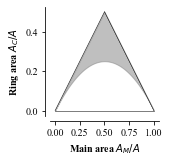

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))

# Fill above the sphere
upper_bound = np.minimum(np.where(A_M_vals <= 0.5, A_M_vals, 1 - A_M_vals), 0.5)

ax.fill_between(A_M_vals, sphere, upper_bound, color='grey', alpha = 0.5)

# Add black diagonal lines
ax.plot(np.linspace(0, 0.5, 1000), np.linspace(0, 0.5, 1000), lw=0.5, color='black')
ax.plot(np.linspace(0.5, 1, 1000), 1 - np.linspace(0.5, 1, 1000), lw=0.5, color='black')
ax.plot(np.linspace(0, 1, 1000), np.zeros(1000), lw=0.5, color='black')

ax.set_xlabel('Main area $A_M/A$', fontweight = 'bold')
ax.set_ylabel('Ring area $A_C/A$', fontweight = 'bold')
ax.set_xticks([0,0.25,0.5,0.75,1])
ax.set_aspect(2)

floating_axes(ax)


# Save plot
plt.savefig(os.path.join(FIGURES, 'Paper', 'phase_space.svg'), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# Shape flow and trajectory

In [18]:
def plot_flow(ax, zeta, kappa = kappa, C0 = C0, t_A = t_A, legend = False):
    # Calculate and plot the flow
    A_M_dot_grid = A_M_dot(A_M_grid, A_C_grid, kappa, zeta, C0, t_A)
    A_C_dot_grid = A_C_dot(A_M_grid, A_C_grid, kappa, zeta, C0)
    ax.streamplot(A_M_grid, A_C_grid, A_M_dot_grid, A_C_dot_grid, color='grey', linewidth = 0.5, zorder = 1)
    
    upper_bound = np.minimum(np.where(A_M_vals <= 0.5, A_M_vals, 1 - A_M_vals), 0.5)

    ax.fill_between(A_M_vals, sphere, upper_bound, color='grey', alpha = 0.5, zorder = 1)
    
    # Plot spherical condition and nullclines
    A_M_dot_contour = ax.contour(A_M_grid, A_C_grid, A_M_dot_grid, levels=0, colors=AMblue, zorder = 3)
    A_C_dot_contour = ax.contour(A_M_grid, A_C_grid, A_C_dot_grid, levels=0, colors='black', zorder = 3)

    # Add black diagonal lines
    ax.plot(np.linspace(0, 0.5, 1000), np.linspace(0, 0.5, 1000), linewidth=0.5, color='black', zorder = 1)
    ax.plot(np.linspace(0.5, 1, 1000), 1 - np.linspace(0.5, 1, 1000), linewidth=0.5, color='black', zorder = 1)
    ax.plot(np.linspace(0, 1, 1000), np.zeros(1000), linewidth=0.5, color='black', zorder = 1)
    
    # Manually create legend handles
    legend_handles = [
    Line2D([0], [0], color=AMblue, linestyle='-', label=r'$\dot{A}_M=0$'),
    Line2D([0], [0], color='black', linestyle='-', label=r'$\dot{A}_C=0$'),
    ]
    if legend:
        # Add the legend
        ax.legend(handles=legend_handles, loc="upper left")
        
    ax.set_xlim([-0.02,1.02])
    ax.set_ylim([-0.02,0.5])
    ax.set_aspect(2)
    
def plot_FP(branch, ax, zeta):
    min_diff_idx = (branch[2] - zeta).abs().idxmin()
    row = branch.loc[min_diff_idx]
    A_M_FP, A_C_FP, stability = row[0], row[1], row[3]

    # Plot based on stability
    if stability == 2:
        ax.scatter(A_M_FP, A_C_FP, marker='o', color='black', edgecolor = 'black', lw=0.5, s=40, zorder=3)
    elif stability == 1:
        ax.scatter(A_M_FP, A_C_FP, marker=MarkerStyle('o', fillstyle='left'), color='black', edgecolor='black', lw=0.5, s=40, zorder=3)
        ax.scatter(A_M_FP, A_C_FP, marker=MarkerStyle('o', fillstyle='right'), color='white', edgecolor='black', lw=0.5, s=40, zorder=3)
    elif stability == 0:
        ax.scatter(A_M_FP, A_C_FP, marker='o', color='white', edgecolor = 'black', lw=0.5, s=40, zorder=3)

In [19]:
# Function to split branches at A_M=A_val/2
def split_side_branch(df):
    left_branch = df[df[0]<0.5]
    right_branch = df[df[0]>0.5]
    return left_branch, right_branch

# Function to split main branch at A_c = A_M - A_M**2
def split_main_branch_shape(df):
    upper_branch = df[df[1]>df[0]-df[0]**2]
    lower_branch = df[df[1]<df[0]-df[0]**2]
    return upper_branch, lower_branch

# Function to split main branch at maximum in zeta
def split_main_branch(df):
    max_index = df[2].idxmax()
    max_value = df.loc[max_index, 1]
    upper_branch = df[df[1]>=max_value]
    lower_branch = df[df[1]<max_value]
    return upper_branch, lower_branch

In [20]:
# Load main and side branches
main_branch = pd.read_csv(os.path.join(directory, 'Main_branch.csv'), header=None)
side_branch_1 = pd.read_csv(os.path.join(directory, 'Side_branch_1.csv'), header=None)
side_branch_2 = pd.read_csv(os.path.join(directory, 'Side_branch_2.csv'), header=None)


# Split branches
main_branch_upper, main_branch_lower = split_main_branch_shape(main_branch)
side_branch_1_left, side_branch_1_right = split_side_branch(side_branch_1)
side_branch_2_left, side_branch_2_right = split_side_branch(side_branch_2)

C:\Users\lenovo\AppData\Local\Temp/ipykernel_30396/2686181727.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.sqrt((1 - ((2 * A_C)/A_M - 1)**2)/A_C)/2
C:\Users\lenovo\AppData\Local\Temp/ipykernel_30396/2686181727.py:2: RuntimeWarning: invalid value encountered in divide
  return np.sqrt((1 - ((2 * A_C)/A_M - 1)**2)/A_C)/2
C:\Users\lenovo\AppData\Local\Temp/ipykernel_30396/2686181727.py:2: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((1 - ((2 * A_C)/A_M - 1)**2)/A_C)/2
C:\Users\lenovo\AppData\Local\Temp/ipykernel_30396/2686181727.py:6: RuntimeWarning: invalid value encountered in sqrt
  return - (A_M - 2 * A_C)/(A_M**2 * np.sqrt(A_M - A_C))/2
C:\Users\lenovo\AppData\Local\Temp/ipykernel_30396/2686181727.py:6: RuntimeWarning: divide by zero encountered in divide
  return - (A_M - 2 * A_C)/(A_M**2 * np.sqrt(A_M - A_C))/2
C:\Users\lenovo\AppData\Local\Temp/ipykernel_30396/2686181727.py:6: RuntimeWarning: invalid value encountered in divide
  ret

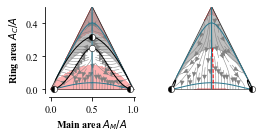

In [22]:
rho = 1/(3*np.sqrt(4*np.pi))

fig_flow, axes = plt.subplots(1, 2, figsize=(4, 2))
axes = axes.flatten()

# zeta_middle
plot_flow(axes[0], zeta_change)
plot_FP(main_branch_upper, axes[0], zeta_change)
plot_FP(main_branch_lower, axes[0], zeta_change)
plot_FP(side_branch_2_left, axes[0], zeta_change)
plot_FP(side_branch_2_right, axes[0], zeta_change)

# Evaluate conditions for neglecting the bending at the contact line
Z_lens = equation_lens(rho, C0, 1, A_M_grid, A_C_grid)
Z_furrow = equation_furrow(rho, C0, 1, A_M_grid, A_C_grid)

mask_lens = Z_lens > 0
mask_furrow = Z_furrow > 0

axes[0].contourf(A_M_grid, A_C_grid, mask_furrow, levels=[0.5, 1], colors = 'red', alpha=0.3, zorder = 0)
axes[0].contourf(A_M_grid, A_C_grid, mask_lens, levels=[0.5, 1], colors = 'red', alpha=0.3, zorder = 0)

# zeta_large
plot_flow(axes[1], 7/3*zeta_change)
plot_FP(side_branch_2_left, axes[1], 7/3*zeta_change)
plot_FP(side_branch_2_right, axes[1], 7/3*zeta_change)

# Evaluate conditions for neglecting the bending at the contact line
Z_lens = equation_lens(rho, C0, 7/3, A_M_grid, A_C_grid)
Z_furrow = equation_furrow(rho, C0, 7/3, A_M_grid, A_C_grid)

mask_lens = Z_lens > 0
mask_furrow = Z_furrow > 0

axes[1].contourf(A_M_grid, A_C_grid, mask_furrow, levels=[0.5, 1], colors = 'red', alpha=0.3, zorder = 0)
axes[1].contourf(A_M_grid, A_C_grid, mask_lens, levels=[0.5, 1], colors = 'red', alpha=0.3, zorder = 0)

# Trajectory
trajectory = pd.read_csv(os.path.join(OUTPUT, 'trajectories_flow', '2D_main.csv'), header=None)
axes[1].plot(trajectory[1].values, trajectory[2].values, linestyle='--', color = 'red', zorder = 4)

axes[0].set_ylabel('Ring area $A_C/A$', fontweight = 'bold')
axes[0].set_xlabel('Main area $A_M/A$', fontweight = 'bold')
axes[0].set_xticks([0,0.5,1])
    
floating_axes(axes[0])

for ax in axes[1:]:
    ax.axis('off')

# Layout & Save
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_flow_combined.svg'), dpi=300)
plt.show()
plt.close(fig_flow)

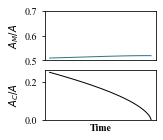

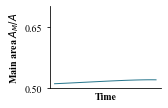

In [23]:
#################################################
# Plot trajectory
fig, axes = plt.subplots(2, 1, figsize=(2, 2), sharex = True)
axes[0].plot(trajectory[0].values, trajectory[1].values, color = AMblue)
axes[1].plot(trajectory[0].values, trajectory[2].values, color = 'black')
axes[1].set_xticks([])
axes[1].set_xlabel('Time', fontweight='bold')

axes[0].set_ylabel(r'$A_M/A$', fontweight='bold')
axes[1].set_ylabel(r'$A_C/A$', fontweight='bold')

axes[0].set_ylim([0.5,0.7])
axes[1].set_ylim([0,0.26])

plt.savefig(os.path.join(FIGURES, 'Paper', 'trajectory.svg'), dpi=300)
plt.show()
plt.close(fig)

# Into one figure
fig, ax = plt.subplots(1, 1, figsize=(2, 1.5))

ax.plot(trajectory[0].values, trajectory[1].values, color = AMblue)
ax.set_xticks([])
ax.set_yticks([0.5, 0.65])
ax.set_ylim([0.5, 0.7])
ax.set_xlabel('Time', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel(r'Main area $A_M/A$', fontweight='bold')
plt.savefig(os.path.join(FIGURES, 'Paper', 'trajectory_simple.svg'), dpi=300)
plt.show()
plt.close(fig)

# Appendix

In [ ]:
t_A = 1/3

## Import bifurcation diagram and plot

In [ ]:
# Function to plot a plane in zeta dimension
def plot_plane_at_x(ax, x_value): 
    # Create a meshgrid 
    y = np.linspace(0, 1, 1000)
    z = np.linspace(0, 0.5, 1000)
    Y, Z = np.meshgrid(y, z) 
    X = np.full_like(Y, x_value) 
    # Plot the surface
    ax.plot_surface(X, Y, Z, color='gray', alpha=0.3, rstride=5, cstride=5)
    
# Function to plot branches in 3D
def plot_branch_3D(branch, ax, x_values=None):
    global bp_label_added, lp_label_added

    branch = branch[branch[2] > 0]
    
    # Stability for unstable FPs, saddles & stable FPs
    stability_styles = {0: ':', 1: '--', 2: '-'}
    
    for stability, linestyle in stability_styles.items():
        subset = branch[branch[3] == stability]
        
        # color if above or below spherical conditions
        mask = (subset[1] <= subset[0]-subset[0]**2)
        furrow = subset[mask]
        lense = subset[~mask]
        
        ax.plot(subset[2].values, subset[0].values, subset[1].values, linestyle=linestyle, color='black', alpha=0.8)
    
    # Scatter points for BP and LP
    bp_points = branch[branch[3] == 3]
    lp_points = branch[(branch[3] == 4) & (branch[1]>0.01)] # Ignore "false" LPs
    
    if not bp_label_added:
        ax.scatter(bp_points[2].values, bp_points[0].values, bp_points[1].values, s=30, color=scatter_colorstyle["BP"], marker = 'd', edgecolor = 'black', label="Branching Point", zorder = 3)
        bp_label_added = True
    else:
        ax.scatter(bp_points[2].values, bp_points[0].values, bp_points[1].values, s=30, color=scatter_colorstyle["BP"], marker = 'd', edgecolor = 'black', zorder = 3)

    if not lp_label_added:
        ax.scatter(lp_points[2].values, lp_points[0].values, lp_points[1].values, s=30, color=scatter_colorstyle["LP"], marker = 'd', edgecolor = 'black', label="Limit Point", zorder = 3)
        lp_label_added = True
    else:
        ax.scatter(lp_points[2].values, lp_points[0].values, lp_points[1].values, s=30, color=scatter_colorstyle["LP"], marker = 'd', edgecolor = 'black', zorder = 3)
    
    # Plot FPs
    if x_values:
        for x_value in x_values:
            idx_closest = (branch[2] - x_value).abs().idxmin()
            FP = branch.loc[idx_closest]
            

            if FP[3] == 2:
                ax.scatter(FP[2], FP[0], FP[1], marker='o', color='black', lw = 0.5, s=40, zorder=3)
            elif FP[3] == 1:
                ax.scatter(FP[2], FP[0], FP[1], marker=MarkerStyle('o', fillstyle='left'), color='black', edgecolor='black', lw = 0.5, s=40, zorder=2)
                ax.scatter(FP[2], FP[0], FP[1], marker=MarkerStyle('o', fillstyle='right'), color='white', edgecolor='black', lw = 0.5, s=40, zorder=2)
            elif FP[3] == 0:
                ax.scatter(FP[2], FP[0], FP[1], marker='o', color='white', edgecolor='black', lw = 0.5, s=40, zorder=3)

# Functions to plot branches in 2D
def plot_branch_A_M(branch, ax, x_values = None):
    branch = branch[branch[2] > 0]
    
    # Stability for unstable FPs, saddles & stable FPs
    stability_styles = {0: ':', 1: '--', 2: '-'}
    
    for stability, linestyle in stability_styles.items():
        subset = branch[branch[3] == stability]
        ax.plot(subset[2].values, subset[0].values, color='black', linestyle=linestyle, zorder = 1)
            
        # Plot FPs
        if x_values:
            for x_value in x_values:
                # Scatter points for FPs
                FP = branch.iloc[(branch[2] - x_value).abs().argmin()]
                
                # Plot FPs based on stability
                if FP[3] == 2:
                    ax.scatter(x_value, FP[0], marker='o', color='black', edgecolor = 'black', lw=0.5, s=40, zorder = 3) 
                elif FP[3] == 1:
                    ax.scatter(x_value, FP[0], marker=MarkerStyle('o', fillstyle='left'), color='black', edgecolor='black', lw=0.5, s=40, zorder=2)
                    ax.scatter(x_value, FP[0], marker=MarkerStyle('o', fillstyle='right'), color='white', edgecolor='black', lw=0.5, s=40, zorder=2)
                elif FP[3] == 0: 
                    ax.scatter(x_value, FP[0], marker='o', color='white', edgecolor = 'black', lw=0.5, s=40, zorder = 3)        

    # Scatter points for BP and LP
    bp_points = branch[branch[3] == 3]
    lp_points = branch[(branch[3] == 4) & (branch[1]>0.01)] # Ignore "false" LPs

    ax.scatter(bp_points[2].values, bp_points[0].values, s=30, color= scatter_colorstyle["BP"], marker = 'd', edgecolor = 'black', lw = 0.5, zorder = 3)
    ax.scatter(lp_points[2].values, lp_points[0].values, s=30, color= scatter_colorstyle["LP"], marker = 'd', edgecolor = 'black', lw = 0.5, zorder = 3)
        
        
def plot_branch_A_C(branch, ax, x_values = None):
    branch = branch[branch[2] > 0]
    
    # Stability for unstable FPs, saddles & stable FPs
    stability_styles = {0: ':', 1: '--', 2: '-'}
    
    for stability, linestyle in stability_styles.items():
        subset = branch[branch[3] == stability]
        
        # color if above or below spherical conditions
        mask = (subset[1] <= subset[0]-subset[0]**2)
        furrow = subset[mask]
        lense = subset[~mask]
        
        ax.plot(subset[2].values, subset[1].values, linestyle=linestyle, color='black', zorder = 1)
            
        # Plot FPs
        if x_values:
            for x_value in x_values:
                # Scatter points for FPs
                FP = branch.iloc[(branch[2] - x_value).abs().argmin()]
                
                # Plot FPs based on stability
                if FP[3] == 2:
                    ax.scatter(x_value, FP[1], marker='o', color='black', edgecolor = 'black', lw=0.5, s=40, zorder = 3) 
                elif FP[3] == 1:
                    ax.scatter(x_value, FP[1], marker=MarkerStyle('o', fillstyle='left'), color='black', edgecolor='black', lw=0.5, s=40, zorder=2)
                    ax.scatter(x_value, FP[1], marker=MarkerStyle('o', fillstyle='right'), color='white', edgecolor='black', lw=0.5, s=40, zorder=2)
                elif FP[3] == 0: 
                    ax.scatter(x_value, FP[1], marker='o', color='white', edgecolor = 'black', lw=0.5, s=40, zorder = 3)        

    # Scatter points for BP and LP
    bp_points = branch[branch[3] == 3]
    lp_points = branch[(branch[3] == 4) & (branch[1]>0.01)] # Ignore "false" LPs

    ax.scatter(bp_points[2].values, bp_points[1].values, s=30, color= scatter_colorstyle["BP"], marker = 'd', edgecolor = 'black', lw=0.5, zorder = 3)
    ax.scatter(lp_points[2].values, lp_points[1].values, s=30, color= scatter_colorstyle["LP"], marker = 'd', edgecolor = 'black', lw=0.5, zorder = 3)
    
def plot_FP(branch, ax, zeta):
    min_diff_idx = (branch[2] - zeta).abs().idxmin()
    row = branch.loc[min_diff_idx]
    A_M_FP, A_C_FP, stability = row[0], row[1], row[3]

    # Plot based on stability
    if stability == 2:
        ax.scatter(A_M_FP, A_C_FP, marker='o', color='black', edgecolor = 'black', lw=0.5, s=40, zorder=3)
    elif stability == 1:
        ax.scatter(A_M_FP, A_C_FP, marker=MarkerStyle('o', fillstyle='left'), color='black', edgecolor='black', lw=0.5, s=40, zorder=3)
        ax.scatter(A_M_FP, A_C_FP, marker=MarkerStyle('o', fillstyle='right'), color='white', edgecolor='black', lw=0.5, s=40, zorder=3)
    elif stability == 0:
        ax.scatter(A_M_FP, A_C_FP, marker='o', color='white', edgecolor = 'black', lw=0.5, s=40, zorder=3)

## Figures

In [16]:
# Line tensions for flow diagrams
zeta = 2*zeta_change/3
zeta_small = zeta_change/3
zeta_middle = zeta_change
zeta_large = 5*zeta_change/4

# Create a formatter that divides by zeta_change
def zeta_formatter(x, pos):
    return f"{x / zeta_change:.2f}"

# x-axis tick positions in absolute values
xticks = [0, zeta_change/3, 2*zeta_change/3, zeta_change, 4*zeta_change/3]

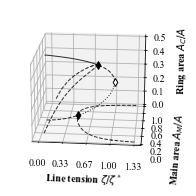

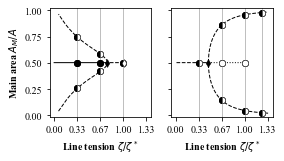

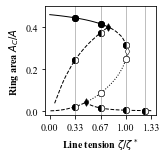

C:\Users\lenovo\AppData\Local\Temp/ipykernel_19932/2686181727.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.sqrt((1 - ((2 * A_C)/A_M - 1)**2)/A_C)/2
C:\Users\lenovo\AppData\Local\Temp/ipykernel_19932/2686181727.py:2: RuntimeWarning: invalid value encountered in divide
  return np.sqrt((1 - ((2 * A_C)/A_M - 1)**2)/A_C)/2
C:\Users\lenovo\AppData\Local\Temp/ipykernel_19932/2686181727.py:2: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((1 - ((2 * A_C)/A_M - 1)**2)/A_C)/2
C:\Users\lenovo\AppData\Local\Temp/ipykernel_19932/2686181727.py:6: RuntimeWarning: invalid value encountered in sqrt
  return - (A_M - 2 * A_C)/(A_M**2 * np.sqrt(A_M - A_C))/2
C:\Users\lenovo\AppData\Local\Temp/ipykernel_19932/2686181727.py:6: RuntimeWarning: divide by zero encountered in divide
  return - (A_M - 2 * A_C)/(A_M**2 * np.sqrt(A_M - A_C))/2
C:\Users\lenovo\AppData\Local\Temp/ipykernel_19932/2686181727.py:6: RuntimeWarning: invalid value encountered in divide
  ret

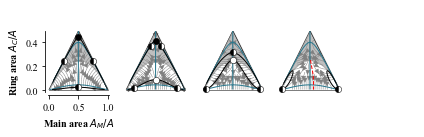

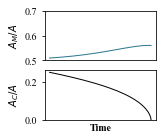

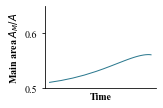

In [ ]:
# Load main and side branches
main_branch = pd.read_csv(os.path.join(directory, 'Main_branch.csv'), header=None)
side_branch_1 = pd.read_csv(os.path.join(directory, 'Side_branch_1.csv'), header=None)
side_branch_2 = pd.read_csv(os.path.join(directory, 'Side_branch_2.csv'), header=None)

main_branch = main_branch[main_branch[2]<4/3*zeta_change]
side_branch_1 = side_branch_1[side_branch_1[2]<4/3*zeta_change]
side_branch_2 = side_branch_2[side_branch_2[2]<4/3*zeta_change]


# Split branches
main_branch_upper, main_branch_lower = split_main_branch_shape(main_branch)
side_branch_1_left, side_branch_1_right = split_side_branch(side_branch_1)
side_branch_2_left, side_branch_2_right = split_side_branch(side_branch_2)

# Convert to correct prefactor
branches = [main_branch_upper, main_branch_lower,
            side_branch_1_left, side_branch_1_right,
            side_branch_2_left, side_branch_2_right]
    
# Define scatter colors for markers
scatter_colorstyle = {"BP": 'black', "LP": 'white'}

####################################################################################
# **3D Bifurcation Diagram**
fig_3D = plt.figure(figsize=(5, 3))
ax3D = fig_3D.add_subplot(111, projection='3d')

bp_label_added = False
lp_label_added = False

plot_branch_3D(main_branch_upper, ax3D)
plot_branch_3D(main_branch_lower, ax3D)
plot_branch_3D(side_branch_1_left, ax3D)
plot_branch_3D(side_branch_1_right, ax3D)
plot_branch_3D(side_branch_2_left, ax3D)
plot_branch_3D(side_branch_2_right, ax3D)

# Viewing angle
ax3D.view_init(elev=20, azim=-85)

# Axis limits and labels
ax3D.set_ylim(0, 1)
ax3D.set_zlim(0, 0.5)

ax3D.set_xticks(xticks)

ax3D.set_xlabel(r"Line tension $\zeta/\zeta^*$", ha='center', fontweight='bold')
ax3D.set_ylabel('Main area $A_M/A$', ha='center', fontweight='bold', labelpad=8)
ax3D.set_zlabel('Ring area $A_C/A$', ha='center', fontweight='bold', labelpad=10)

ax3D.xaxis.set_major_formatter(FuncFormatter(zeta_formatter)) # align zeta scaling

# Save 3D plot **without labels or legend**
plt.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_3D_appendix.svg'), dpi=300, bbox_inches='tight')
plt.show()

# Close figures to free memory
plt.close(fig_3D)

####################################################################################
# **2D Bifurcation Diagrams**
figM, (axM1, axM2) = plt.subplots(1, 2, figsize=(4, 2), sharex=True, sharey=True)
figC, axC = plt.subplots(1, 1, figsize=(2,2))

plot_branch_A_C(main_branch_upper, axC, x_values = [zeta, zeta_small, zeta_middle-0.01])
plot_branch_A_C(main_branch_lower, axC, x_values = [zeta, zeta_small, zeta_middle])
plot_branch_A_M(main_branch_upper, axM1, x_values = [zeta, zeta_small, zeta_middle-0.01])
plot_branch_A_M(main_branch_lower, axM2, x_values = [zeta, zeta_small, zeta_middle])

plot_branch_A_C(side_branch_1_left, axC, x_values=[zeta, zeta_small])
plot_branch_A_C(side_branch_2_left, axC, x_values=[zeta, zeta_large, zeta_middle])
plot_branch_A_M(side_branch_1_left, axM1, x_values=[zeta, zeta_small])
plot_branch_A_M(side_branch_1_right, axM1, x_values=[zeta, zeta_small])
plot_branch_A_M(side_branch_2_left, axM2, x_values=[zeta, zeta_large, zeta_middle])
plot_branch_A_M(side_branch_2_right, axM2, x_values=[zeta, zeta_large, zeta_middle])

# Add vertical reference line
for ax in [axM1, axM2, axC]:
    ax.axvline(x=zeta, color='grey', alpha=0.5)
    ax.axvline(x=zeta_small, color='grey', alpha=0.5)
    ax.axvline(x=zeta_middle, color='grey', alpha=0.5)

axM2.axvline(x=zeta_large, color='grey', alpha=0.5)
axC.axvline(x=zeta_large, color='grey', alpha=0.5)

# Labels and limits
axC.set_ylabel('Ring area $A_C/A$', fontweight='bold')
axC.set_ylim(-0.02, 0.5)
axC.set_xlabel(r"Line tension $\zeta/\zeta^*$", fontweight='bold')

axM1.set_ylabel('Main area $A_M/A$', fontweight='bold')
axM1.set_ylim(-0.02, 1.02)
axM1.set_xlabel(r"Line tension $\zeta/\zeta^*$", fontweight='bold')

axM2.set_ylim(-0.02, 1.02)
axM2.set_xlabel(r"Line tension $\zeta/\zeta^*$", fontweight='bold')

axC.grid(False)
axM1.grid(False)
axM2.grid(False)

# align zeta scaling
for ax in [axM1, axM2, axC]:
    ax.xaxis.set_major_formatter(FuncFormatter(zeta_formatter))
    ax.set_xticks(xticks)

# Save 2D plots
figM.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_2D_M_appendix.svg'), dpi=300, bbox_inches='tight')
figC.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_2D_c_appendix.svg'), dpi=300, bbox_inches='tight')
plt.show()
plt.close(figM)
plt.close(figC)

####################################################################################
# **Flow Diagrams - Combined into one wide figure**

fig_flow, axes = plt.subplots(1, 5, figsize=(6, 2))
axes = axes.flatten()

# Panel 1: zeta_small
plot_flow(axes[0], zeta_small)
plot_FP(main_branch_upper, axes[0], zeta_small)
plot_FP(main_branch_lower, axes[0], zeta_small)
plot_FP(side_branch_1_left, axes[0], zeta_small)
plot_FP(side_branch_1_right, axes[0], zeta_small)

# Panel 2: zeta
plot_flow(axes[1], zeta)
plot_FP(main_branch_upper, axes[1], zeta)
plot_FP(main_branch_lower, axes[1], zeta)
plot_FP(side_branch_1_left, axes[1], zeta)
plot_FP(side_branch_1_right, axes[1], zeta)
plot_FP(side_branch_2_left, axes[1], zeta)
plot_FP(side_branch_2_right, axes[1], zeta)

# Panel 3: zeta_middle
plot_flow(axes[2], zeta_middle)
plot_FP(main_branch_upper, axes[2], zeta_middle)
plot_FP(main_branch_lower, axes[2], zeta_middle)
plot_FP(side_branch_2_left, axes[2], zeta_middle)
plot_FP(side_branch_2_right, axes[2], zeta_middle)

# Panel 4: zeta_large
plot_flow(axes[3], zeta_large)
plot_FP(side_branch_2_left, axes[3], zeta_large)
plot_FP(side_branch_2_right, axes[3], zeta_large)

# Trajectory
trajectory = pd.read_csv(os.path.join(OUTPUT, 'trajectories_flow', '2D_appendix.csv'), header=None)
axes[3].plot(trajectory[1].values, trajectory[2].values, color = 'red', zorder = 4, linestyle = '--')

axes[0].set_ylabel('Ring area $A_C/A$', fontweight = 'bold')

for ax in axes:
    ax.set_xlabel('Main area $A_M/A$', fontweight = 'bold')

axes[0].set_xticks([0,0.5,1])
floating_axes(axes[0])

for ax in axes[1:]:
    ax.axis('off')

# Layout & Save
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'Paper', 'bifurcation_flow_combined_appendix.svg'), dpi=300)
plt.show()
plt.close(fig_flow)

#################################################
# Plot trajectory
fig, axes = plt.subplots(2, 1, figsize=(2, 2), sharex = True)
axes[0].plot(trajectory[0].values, trajectory[1].values, color = AMblue)
axes[1].plot(trajectory[0].values, trajectory[2].values, color = 'black')
axes[1].set_xticks([])
axes[1].set_xlabel('Time', fontweight='bold')

axes[0].set_ylabel(r'$A_M/A$', fontweight='bold')
axes[1].set_ylabel(r'$A_C/A$', fontweight='bold')

axes[0].set_ylim([0.5,0.7])
axes[1].set_ylim([0,0.26])

plt.savefig(os.path.join(FIGURES, 'Paper', 'trajectory_appendix.svg'), dpi=300)
plt.show()
plt.close(fig)

# Into one figure
fig, ax = plt.subplots(1, 1, figsize=(2, 1.5))

ax.plot(trajectory[0].values, trajectory[1].values, color = AMblue)
ax.set_xticks([])
ax.set_yticks([0.5, 0.6])
ax.set_ylim([0.5, 0.65])
ax.set_xlabel('Time', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel(r'Main area $A_M/A$', fontweight='bold')
plt.savefig(os.path.join(FIGURES, 'Paper', 'trajectory_simple_appendix.svg'), dpi=300)
plt.show()
plt.close(fig)